Dataset Shape: (200, 5)
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


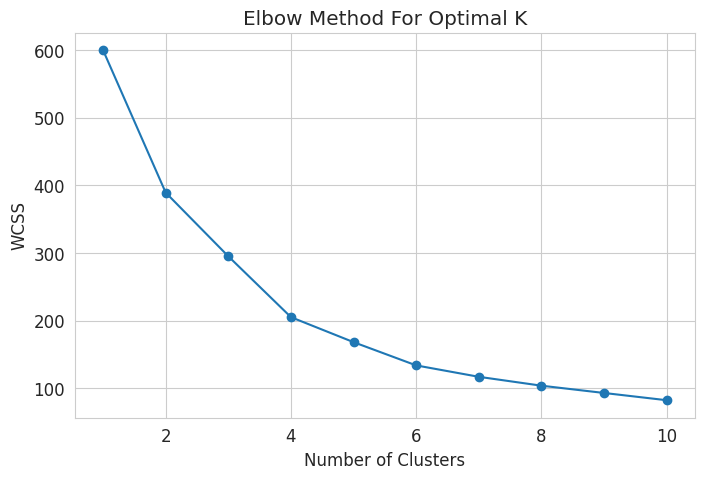


Customer Segment Summary
               Age     Income  SpendingScore
cluster                                     
0        46.250000  26.750000      18.350000
1        25.185185  41.092593      62.240741
2        32.875000  86.100000      81.525000
3        39.871795  86.102564      19.358974
4        55.638298  54.382979      48.851064


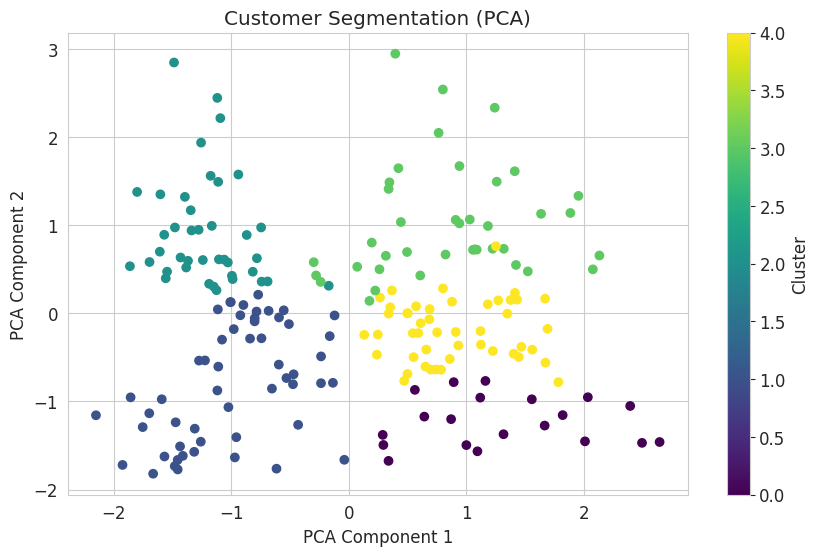


Customers Per Segment
cluster
0    20
1    54
2    40
3    39
4    47
Name: count, dtype: int64

File Saved Successfully:
customer_segments_output.csv

Cluster Profiles
               Age     Income  SpendingScore
cluster                                     
0        46.250000  26.750000      18.350000
1        25.185185  41.092593      62.240741
2        32.875000  86.100000      81.525000
3        39.871795  86.102564      19.358974
4        55.638298  54.382979      48.851064

Interpretation Example (based on average values in each cluster):
Cluster 0 (Target Customers): Low Income, High SpendingScore
Cluster 1 (Standard Customers): Medium Income, Medium SpendingScore
Cluster 2 (Careful Customers): High Income, Low SpendingScore
Cluster 3 (Sensible Customers): Low Income, Low SpendingScore
Cluster 4 (VIP Customers): High Income, High SpendingScore


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
df = pd.read_csv("Mall_Customers.csv", sep=",")

print("Dataset Shape:", df.shape)
print(df.head())

df = df.dropna()
df = df.rename(columns={'Annual Income (k$)': 'Income', 'Spending Score (1-100)': 'SpendingScore'})
features = [
    "Age",
    "Income",
    "SpendingScore"
]

X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker="o")
plt.title("Elbow Method For Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()


k = 5
kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X_scaled)

summary = df.groupby("cluster")[
    ["Age", "Income", "SpendingScore"]
].mean()

print("\nCustomer Segment Summary")
print(summary)

pca = PCA(n_components=2)

pca_result = pca.fit_transform(X_scaled)

df["pca1"] = pca_result[:, 0]
df["pca2"] = pca_result[:, 1]

plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    df["pca1"],
    df["pca2"],
    c=df["cluster"],
    cmap="viridis"
)

plt.title("Customer Segmentation (PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.colorbar(scatter, label="Cluster")

plt.show()
print("\nCustomers Per Segment")
print(df["cluster"].value_counts().sort_index())
df.to_csv(
    "customer_segments_output.csv",
    index=False
)

print("\nFile Saved Successfully:")
print("customer_segments_output.csv")
cluster_profile = df.groupby("cluster")[
    ["Age", "Income", "SpendingScore"]
].mean()

print("\nCluster Profiles")
print(cluster_profile)

print("\nInterpretation Example (based on average values in each cluster):")
print("Cluster 0 (Target Customers): Low Income, High SpendingScore")
print("Cluster 1 (Standard Customers): Medium Income, Medium SpendingScore")
print("Cluster 2 (Careful Customers): High Income, Low SpendingScore")
print("Cluster 3 (Sensible Customers): Low Income, Low SpendingScore")
print("Cluster 4 (VIP Customers): High Income, High SpendingScore")